In [1]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.stats import binned_statistic_2d
from scipy.interpolate import RegularGridInterpolator
import pickle
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm, rgb2hex

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

from pipelines.l3_pipeline import L3DatasetLoader
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load the trained DBSCAN model
model_path = r"E:\satdata\Custom\dbscan_model_optimal_2005_2011_full.pkl"

print("Loading trained model...")
with open(model_path, 'rb') as f:
    model_data = pickle.load(f)

# Extract model components
dbscan = model_data['dbscan_model']
scaler = model_data['scaler']
lat_centers = model_data['lat_centers']
lon_centers = model_data['lon_centers']
lat_edges = model_data['lat_edges']
lon_edges = model_data['lon_edges']
bbox = model_data['bbox']
grid_shape = model_data['grid_shape']
eps = model_data['eps']
min_samples = model_data['min_samples']
n_clusters = model_data['n_clusters']
training_years = model_data['training_years']

lon_min, lon_max, lat_min, lat_max = bbox
lat_bins, lon_bins = grid_shape

print("\n" + "=" * 80)
print("MODEL INFORMATION")
print("=" * 80)
print(f"  Training period: {training_years[0]}-{training_years[-1]} (June-November)")
print(f"  Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")
print(f"  Grid: {lat_bins} x {lon_bins}")
print(f"  DBSCAN parameters: eps={eps:.4f}, min_samples={min_samples}")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points: {model_data['n_noise']} ({100*model_data['n_noise']/len(model_data['training_labels']):.1f}%)")
print("=" * 80)

Loading trained model...

MODEL INFORMATION
  Training period: 2010-2011 (June-November)
  Region: [-94.0, 27.5] to [-88.0, 30.5]
  Grid: 200 x 300
  DBSCAN parameters: eps=0.0159, min_samples=4
  Clusters found: 672
  Noise points: 3538 (7.9%)


In [3]:
# Recreate cluster map from training data
training_labels = model_data['training_labels']
training_sst = model_data['training_sst']
training_chlor = model_data['training_chlor']

# Create colormap for clusters
unique_labels = sorted(set(training_labels))
cluster_labels = [l for l in unique_labels if l != -1]
cluster_labels_sorted = sorted(cluster_labels)

# Use viridis colormap for all clusters
palette_colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_sorted)))
palette = [rgb2hex(c) for c in palette_colors]

cmap_colors = ['#808080'] + palette[:len(cluster_labels_sorted)]
cmap = ListedColormap(cmap_colors)
bounds = np.arange(0, len(cluster_labels_sorted) + 2) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

# Map labels to plot indices (noise=0, clusters=1,2,3...)
label_to_idx = {-1: 0}
for i, cl in enumerate(cluster_labels_sorted):
    label_to_idx[cl] = i + 1

print(f"Cluster mapping: {label_to_idx}")

Cluster mapping: {-1: 0, np.int64(0): 1, np.int64(1): 2, np.int64(2): 3, np.int64(3): 4, np.int64(4): 5, np.int64(5): 6, np.int64(6): 7, np.int64(7): 8, np.int64(8): 9, np.int64(9): 10, np.int64(10): 11, np.int64(11): 12, np.int64(12): 13, np.int64(13): 14, np.int64(14): 15, np.int64(15): 16, np.int64(16): 17, np.int64(17): 18, np.int64(18): 19, np.int64(19): 20, np.int64(20): 21, np.int64(21): 22, np.int64(22): 23, np.int64(23): 24, np.int64(24): 25, np.int64(25): 26, np.int64(26): 27, np.int64(27): 28, np.int64(28): 29, np.int64(29): 30, np.int64(30): 31, np.int64(31): 32, np.int64(32): 33, np.int64(33): 34, np.int64(34): 35, np.int64(35): 36, np.int64(36): 37, np.int64(37): 38, np.int64(38): 39, np.int64(39): 40, np.int64(40): 41, np.int64(41): 42, np.int64(42): 43, np.int64(43): 44, np.int64(44): 45, np.int64(45): 46, np.int64(46): 47, np.int64(47): 48, np.int64(48): 49, np.int64(49): 50, np.int64(50): 51, np.int64(51): 52, np.int64(52): 53, np.int64(53): 54, np.int64(54): 55, np.i

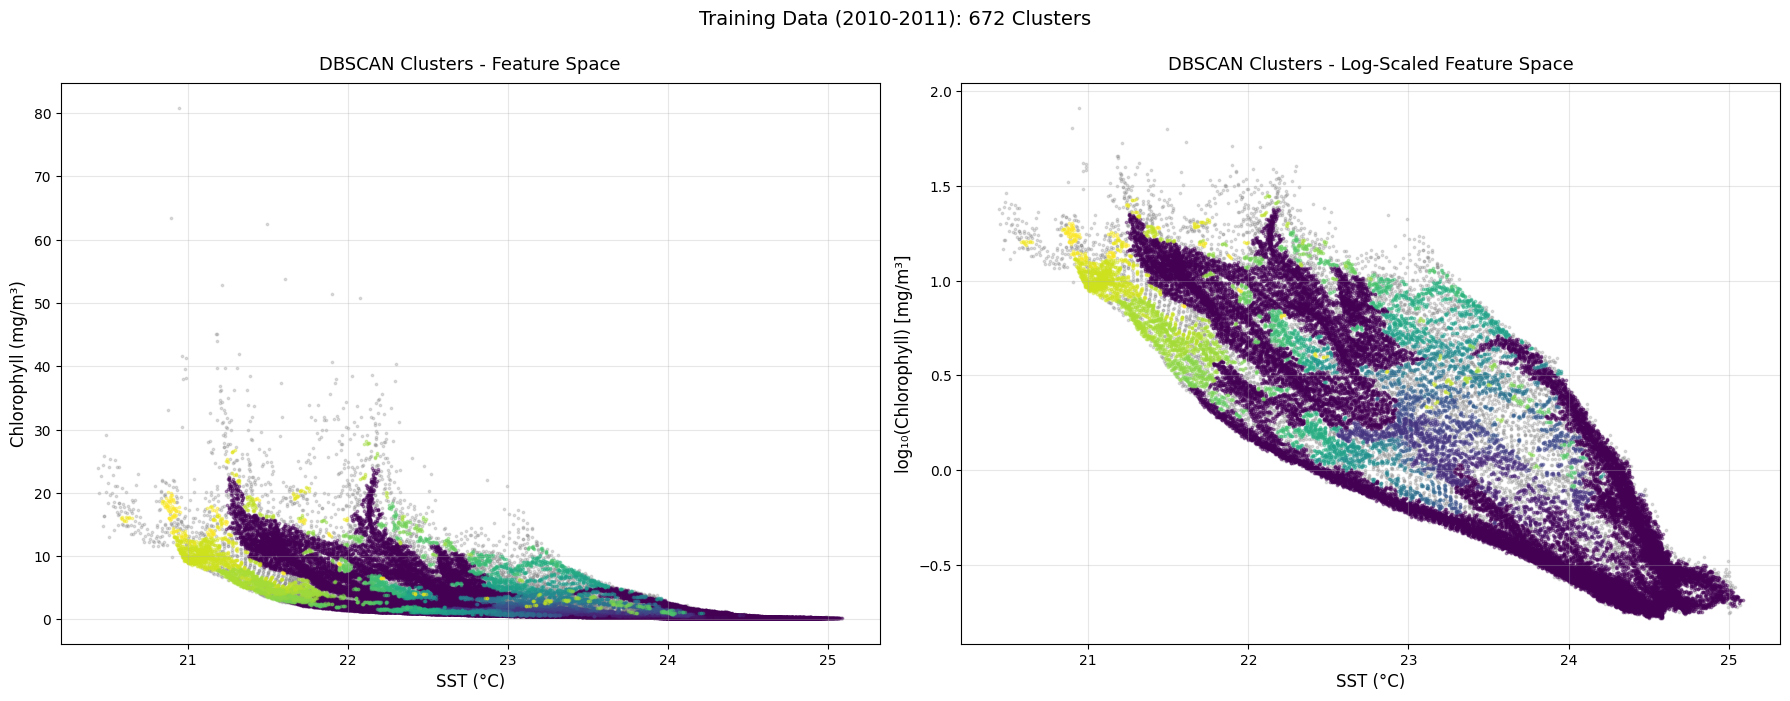

In [4]:
# Visualize feature space
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_map = {-1: '#808080'}
for i, cl in enumerate(cluster_labels_sorted):
    colors_map[cl] = palette[i]

# Left: Scaled features
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[0].scatter(training_sst[mask], training_chlor[mask], 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[0].set_xlabel('SST (°C)', fontsize=12)
axes[0].set_ylabel('Chlorophyll (mg/m³)', fontsize=12)
axes[0].set_title('DBSCAN Clusters - Feature Space', fontsize=13, pad=10)
axes[0].grid(True, alpha=0.3)
# axes[0].legend(loc='best', fontsize=9, markerscale=3)

# Right: Log-transformed chlorophyll
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[1].scatter(training_sst[mask], np.log10(training_chlor[mask]), 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[1].set_xlabel('SST (°C)', fontsize=12)
axes[1].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
axes[1].set_title('DBSCAN Clusters - Log-Scaled Feature Space', fontsize=13, pad=10)
axes[1].grid(True, alpha=0.3)
# axes[1].legend(loc='best', fontsize=9, markerscale=3)

plt.suptitle(f'Training Data ({training_years[0]}-{training_years[-1]}): {n_clusters} Clusters', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

In [6]:
sst_var = 'analysed_sst'
chlor_var = 'chlor_a'
chlor_group = 'geophysical_data'

sst_base_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-01-01_{year}-12-31"
chlor_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-01-01_{year}-12-31"


LOADING 2010-2011 DATA WITH TIMESTAMPS

--- Processing 2010 ---
  SST files: 366
  Chlorophyll files: 566
  SST files: 366
  Chlorophyll files: 566

--- Processing 2011 ---
  SST files: 153
  Chlorophyll files: 587

Total data points collected: 23,708,564
Date range: 2010-01-01 00:00:00 to 2011-12-31 00:00:00


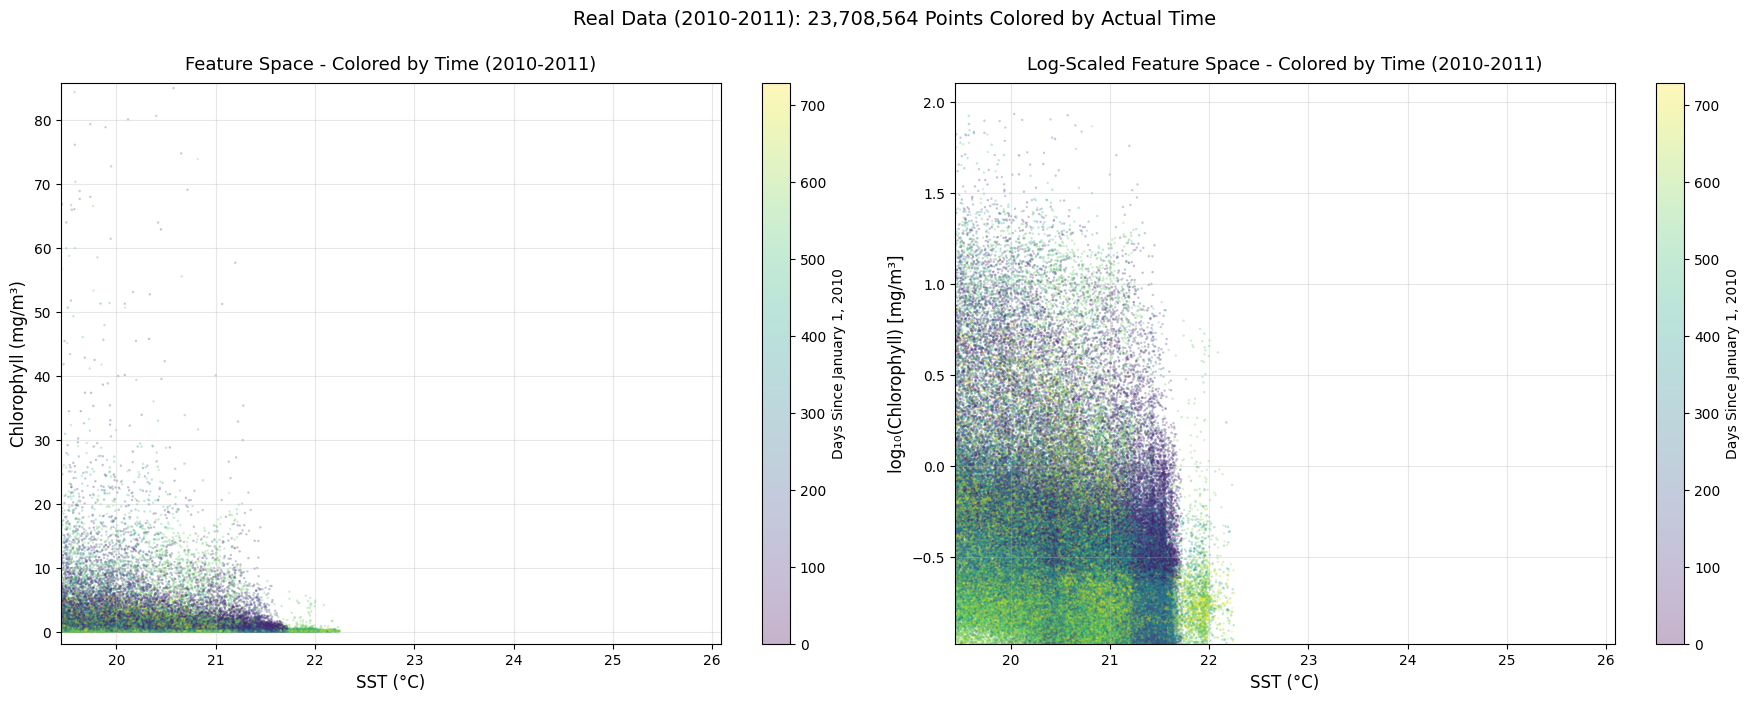


✓ Visualization complete with REAL temporal data
   Time range: 0 to 729 days


In [8]:
# Load REAL data from 2010-2011 and visualize by actual time
print("\n" + "=" * 80)
print("LOADING 2010-2011 DATA WITH TIMESTAMPS")
print("=" * 80)

# Years to load (full year from January 1 to December 31)
load_years = [2010, 2011]
load_start = '2010-01-01'
load_end = '2011-12-31'

# Storage for all data points with timestamps
all_sst_data = []
all_chlor_data = []
all_timestamps = []

for year in load_years:
    print(f"\n--- Processing {year} ---")
    
    # Load SST files
    sst_dir = sst_base_pattern.format(year=year)
    year_sst_files = sorted(glob.glob(os.path.join(sst_dir, '*.nc')))
    
    sst_files_filtered = []
    for sst_file in year_sst_files:
        try:
            with xr.open_dataset(sst_file) as ds:
                file_time = pd.to_datetime(ds.time.values[0])
                if pd.Timestamp(load_start) <= file_time <= pd.Timestamp(load_end):
                    sst_files_filtered.append(sst_file)
        except:
            continue
    
    print(f"  SST files: {len(sst_files_filtered)}")
    
    # Load chlorophyll files
    chlor_dir = chlor_base_pattern.format(year=year)
    year_chlor_files = glob.glob(os.path.join(chlor_dir, '**', '*.nc'), recursive=True)
    
    chlor_files_filtered = []
    chlor_dates = []
    for chlor_file in year_chlor_files:
        filename = os.path.basename(chlor_file)
        try:
            if 'AQUA_MODIS' in filename or 'MODIS' in filename:
                parts = filename.split('.')
                if len(parts) > 1:
                    date_str = parts[1][:8]
                    file_date = pd.to_datetime(date_str, format='%Y%m%d')
                    if pd.Timestamp(load_start) <= file_date <= pd.Timestamp(load_end):
                        chlor_files_filtered.append(chlor_file)
                        chlor_dates.append(file_date)
        except:
            continue
    
    print(f"  Chlorophyll files: {len(chlor_files_filtered)}")
    
    # Process each chlorophyll file with its timestamp
    if len(chlor_files_filtered) > 0:
        chlor_loader_temp = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
        
        # Load SST for interpolation
        sst_loader_temp = L3DatasetLoader(variables=[sst_var], bbox=(lon_min, lon_max, lat_min, lat_max))
        sst_datasets_temp = sst_loader_temp.load_multiple(sst_files_filtered[:min(30, len(sst_files_filtered))])
        
        sst_list_temp = []
        for ds in sst_datasets_temp:
            sst_k = ds[sst_var].values.squeeze()
            sst_c = sst_k - 273.15
            sst_c[(sst_c < -2) | (sst_c > 35)] = np.nan
            sst_list_temp.append(sst_c)
        
        sst_mean_temp = np.nanmean(np.stack(sst_list_temp, axis=0), axis=0)
        lat_sst_temp = sst_datasets_temp[0]['lat'].values
        lon_sst_temp = sst_datasets_temp[0]['lon'].values
        
        # Create SST interpolator
        sst_interp = RegularGridInterpolator(
            (lat_sst_temp, lon_sst_temp), sst_mean_temp,
            method='linear', bounds_error=False, fill_value=np.nan
        )
        
        # Process chlorophyll files (increased limit to get more temporal coverage)
        for chlor_file, chlor_date in zip(chlor_files_filtered, chlor_dates):
            try:
                # Load single file using load_multiple with a list
                ds_list = chlor_loader_temp.load_multiple([chlor_file])
                if ds_list and len(ds_list) > 0:
                    ds = ds_list[0]
                    lat = ds['lat'].values.flatten()
                    lon = ds['lon'].values.flatten()
                    chlor = ds[chlor_var].values.flatten()
                    
                    # Filter valid points (use same criteria as training)
                    valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & 
                            (chlor > 0) & (chlor < 100) &
                            (lat >= lat_min) & (lat <= lat_max) &
                            (lon >= lon_min) & (lon <= lon_max))
                    
                    if np.sum(valid) > 0:
                        # Get corresponding SST values
                        points = np.column_stack([lat[valid], lon[valid]])
                        sst_vals = sst_interp(points)
                        
                        # Keep only points with valid SST
                        valid_sst = ~np.isnan(sst_vals)
                        
                        if np.sum(valid_sst) > 0:
                            all_sst_data.extend(sst_vals[valid_sst])
                            all_chlor_data.extend(chlor[valid][valid_sst])
                            all_timestamps.extend([chlor_date] * np.sum(valid_sst))
            except Exception as e:
                continue  # Silently skip errors

# Convert to arrays
all_sst_data = np.array(all_sst_data)
all_chlor_data = np.array(all_chlor_data)
all_timestamps = np.array(all_timestamps)

print(f"\n" + "=" * 80)
print(f"Total data points collected: {len(all_sst_data):,}")
print(f"Date range: {all_timestamps.min()} to {all_timestamps.max()}")
print(f"=" * 80)

# Convert timestamps to numeric (days since January 1, 2010)
if len(all_timestamps) > 0:
    start_date = pd.Timestamp('2010-01-01')
    days_from_start = np.array([(pd.Timestamp(t) - start_date).days for t in all_timestamps])
    
    # Create the figure
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Subsample for plotting if too many points
    if len(all_sst_data) > 500000:
        idx = np.random.choice(len(all_sst_data), 500000, replace=False)
        plot_sst = all_sst_data[idx]
        plot_chlor = all_chlor_data[idx]
        plot_time = days_from_start[idx]
    else:
        plot_sst = all_sst_data
        plot_chlor = all_chlor_data
        plot_time = days_from_start
    
    # Left: Regular scale (match training data axes)
    scatter1 = axes[0].scatter(plot_sst, plot_chlor, 
                               c=plot_time, cmap='viridis', alpha=0.3, s=3, edgecolors='none')
    axes[0].set_xlabel('SST (°C)', fontsize=12)
    axes[0].set_ylabel('Chlorophyll (mg/m³)', fontsize=12)
    axes[0].set_title('Feature Space - Colored by Time (2010-2011)', fontsize=13, pad=10)
    axes[0].set_xlim([training_sst.min() - 1, training_sst.max() + 1])
    axes[0].set_ylim([training_chlor.min() - 2, training_chlor.max() + 5])
    axes[0].grid(True, alpha=0.3)
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label('Days Since January 1, 2010', fontsize=10)
    
    # Right: Log-transformed chlorophyll (match training data axes)
    scatter2 = axes[1].scatter(plot_sst, np.log10(plot_chlor), 
                               c=plot_time, cmap='viridis', alpha=0.3, s=3, edgecolors='none')
    axes[1].set_xlabel('SST (°C)', fontsize=12)
    axes[1].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
    axes[1].set_title('Log-Scaled Feature Space - Colored by Time (2010-2011)', fontsize=13, pad=10)
    axes[1].set_xlim([training_sst.min() - 1, training_sst.max() + 1])
    axes[1].set_ylim([np.log10(training_chlor.min()) - 0.2, np.log10(training_chlor.max()) + 0.2])
    axes[1].grid(True, alpha=0.3)
    cbar2 = plt.colorbar(scatter2, ax=axes[1])
    cbar2.set_label('Days Since January 1, 2010', fontsize=10)
    
    plt.suptitle(f'Real Data (2010-2011): {len(all_sst_data):,} Points Colored by Actual Time', 
                 fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Visualization complete with REAL temporal data")
    print(f"   Time range: {days_from_start.min():.0f} to {days_from_start.max():.0f} days")
else:
    print("No data loaded")